### Background Info

- Manipulate and prepare the provided customer booking data to build a predictive model
- It's important to interpret the results in order to understand how "predictive" the data really is
- Evaluate the model’s performance and output how each variable contributes to the predictive model’s power.

### Task

**1. Explore and prepare the dataset**
- Explore `customer_booking.csv` (columns, dtypes, distributions, missing/invalid values).
- Engineer new features where useful, then prepare the data for modelling (encoding, scaling, etc.).

**2. Train a machine learning model**
- Predict `booking_complete` (whether the customer completes a booking).
- Use an algorithm that exposes feature-level contributions to predictive power (e.g. RandomForest).

**3. Evaluate the model and present findings**
- Cross-validate and report appropriate evaluation metrics.
- Visualise feature importance to interpret what drives the model.
- Summarise findings on a single slide (PowerPoint template, in Resources) for the manager — this is the final submission.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"C:\Users\nmark\Code\BA_Forage\ba-forage-data-science\data\customer_booking.csv", encoding="latin1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 5.3 MB


In [4]:
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

Duplicate rows: 719


In [5]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [6]:
categorical_cols = df.select_dtypes(include="str").columns.tolist()
binary_cols = [c for c in df.columns if df[c].nunique() == 2]

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))
    print()

for col in binary_cols:
    print(f"{col}:")
    print(df[col].value_counts(dropna=False))
    print()

sales_channel: 2 unique values
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

trip_type: 3 unique values
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

flight_day: 7 unique values
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

route: 799 unique values
route
AKLKUL    2680
PENTPE     924
MELSGN     842
ICNSIN     801
DMKKIX     744
ICNSYD     695
DMKPER     679
DPSICN     666
DMKOOL     655
MELPEN     649
Name: count, dtype: int64

booking_origin: 104 unique values
booking_origin
Australia      17872
Malaysia        7174
South Korea     4559
Japan           3885
China           3387
Indonesia       2369
Taiwan          2077
Thailand        2030
India           1270
New Zealand     1074
Name: count, dtype: int64

sales_channel:
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

wants_extra_baggage:
wants_extra

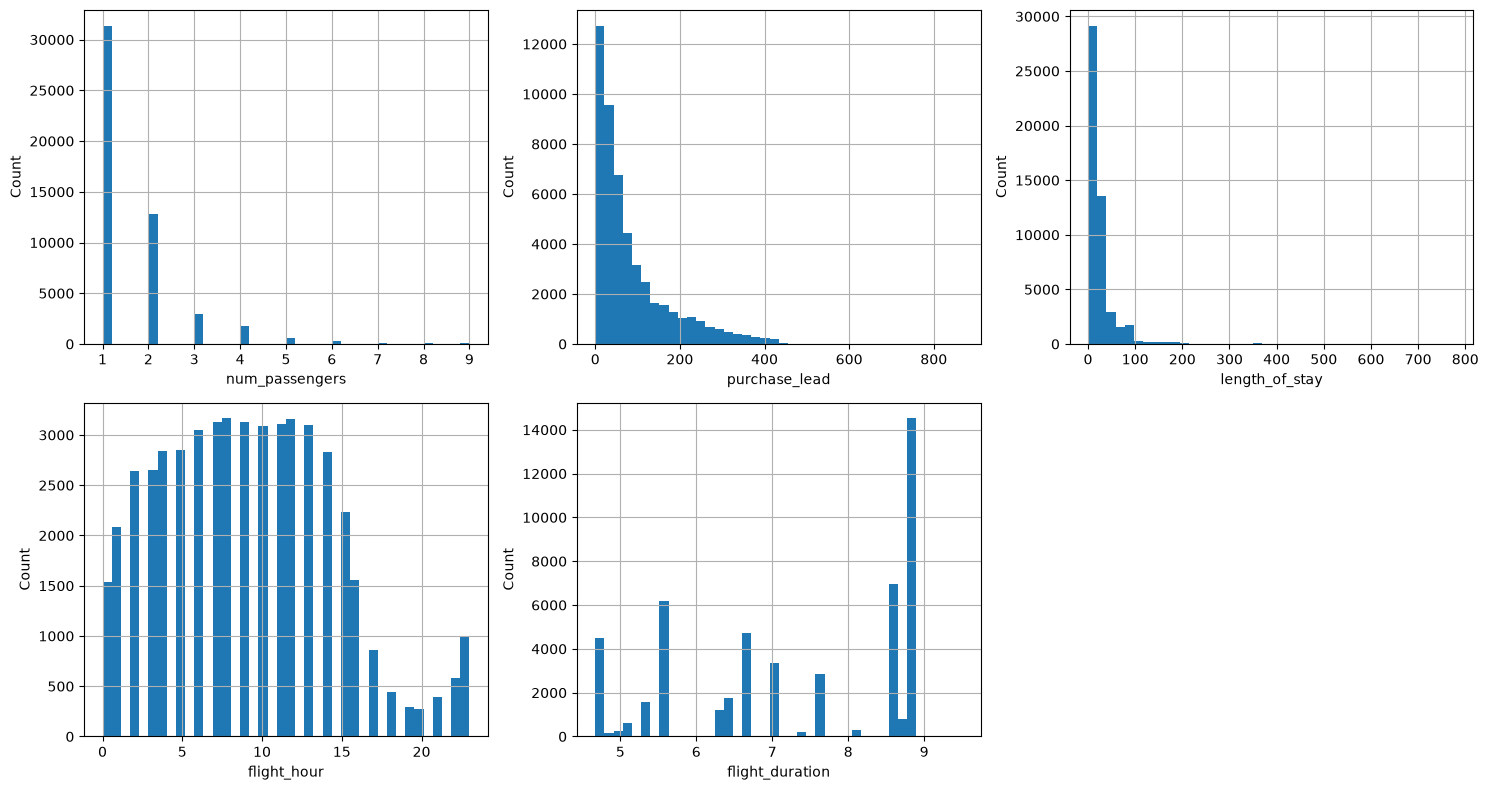

purchase_lead: upper IQR fence=256, max=867, rows above fence=3456
length_of_stay: upper IQR fence=62, max=778, rows above fence=3807


In [7]:
import matplotlib.pyplot as plt

numeric_cols = ["num_passengers", "purchase_lead", "length_of_stay", "flight_hour", "flight_duration"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numeric_cols):
    df[col].hist(bins=40, ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
axes.flat[-1].set_visible(False)
plt.tight_layout()
fig.savefig(r"C:\Users\nmark\Code\BA_Forage\ba-forage-data-science\outputs\numeric_distributions.png", dpi=150)
plt.show()

for col in ["purchase_lead", "length_of_stay"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    upper_fence = q3 + 1.5 * (q3 - q1)
    print(f"{col}: upper IQR fence={upper_fence:.0f}, "
          f"max={df[col].max()}, rows above fence={(df[col] > upper_fence).sum()}")

### Findings: exploration summary

- **Issues**
  - Duplicate rows
  - 84 rows have `booking_origin == "(not set)"` — a missing value disguised as a string, not caught by `df.isna()`
  - `"Czech Republic"` and `"Czechia"` both appear as separate values for the same country

- **Shape**: 50,000 rows × 14 columns. 
  - No missing values in any column. 
  - **719 exact duplicate rows** — drop these before modelling

- **Target (`booking_complete`)**: 
  - 15% of bookings complete (7,478 / 50,000) -> plain accuracy will be misleading.

- **Categoricals**:
  - `sales_channel`: dominated by Internet (44,382) vs. Mobile (5,618).
  - `trip_type`: overwhelmingly RoundTrip (49,497); OneWay/CircleTrip are rare (<1% combined) — low variance, likely weak predictor.
  - `flight_day`: fairly even across the week (Mon highest ~8.1k, Sat lowest ~5.8k).
  - `route` (799 unique) and `booking_origin` (104 unique) are high-cardinality

  - Binary flags (`wants_extra_baggage`, `wants_preferred_seat`, `wants_in_flight_meals`) are all reasonably balanced (30-67% split), so likely useful signal.

## Data Cleanup

- Remove the duplicate rows
- Consider encoding `route`/`booking_origin` given their large cardinality

In [8]:
df = df.drop_duplicates()
df.shape

(49281, 14)

In [9]:
df["booking_origin"] = df["booking_origin"].replace({"Czechia": "Czech Republic"})
df["booking_origin"].value_counts()[["Czech Republic"]]

booking_origin
Czech Republic    9
Name: count, dtype: int64

## Feature Prep

- Converting categorical data into indicator variables

In [10]:
df_encoded = pd.get_dummies(df, columns=["sales_channel", "trip_type", "flight_day"], drop_first=False)

df_encoded["route_freq"] = df["route"].map(df["route"].value_counts())
df_encoded["booking_origin_freq"] = df["booking_origin"].map(df["booking_origin"].value_counts())
df_encoded = df_encoded.drop(columns=["route", "booking_origin"])

df_encoded.head()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete,sales_channel_Internet,...,trip_type_RoundTrip,flight_day_Fri,flight_day_Mon,flight_day_Sat,flight_day_Sun,flight_day_Thu,flight_day_Tue,flight_day_Wed,route_freq,booking_origin_freq
0,2,262,19,7,1,0,0,5.52,0,True,...,True,False,False,True,False,False,False,False,20,1060
1,1,112,20,3,0,0,0,5.52,0,True,...,True,False,False,True,False,False,False,False,20,1060
2,2,243,22,17,1,1,0,5.52,0,True,...,True,False,False,False,False,False,False,True,20,1258
3,1,96,31,4,0,0,1,5.52,0,True,...,True,False,False,True,False,False,False,False,20,1060
4,2,68,22,15,1,0,1,5.52,0,True,...,True,False,False,False,False,False,False,True,20,1258


## Model Training Plan

**1. Separate features from target** — everything except `booking_complete` becomes `X`, and `booking_complete` becomes `y`.

**2. Train/test split — stratified.** Only ~15% of rows are `booking_complete=1`, so a plain random split could give a test set with a noticeably different positive rate than train, making evaluation unreliable. Stratifying on `y` preserves that ~15/85 ratio in both splits.

**3. Train a RandomForestClassifier**
- `class_weight="balanced"` reweights the loss so the rare positive class isn't ignored — without it, the model could get ~85% accuracy just by predicting "no" every time.
- No feature scaling needed — tree splits are threshold-based per feature, not distance-based, so RandomForest is invariant to feature scale.
- `n_estimators` (number of trees) in the low hundreds is a reasonable default; more trees gives more stable predictions with diminishing returns.

**4. Cross-validate, not just a single split.** Stratified K-fold cross-validation on the training data gives the mean/spread of each metric across folds — a far more robust estimate than one train/test split, and shows whether performance is stable or just got lucky once.

**5. Metrics — deliberately not plain accuracy.** ROC-AUC, precision, recall, and F1 for the positive class. With an 85/15 imbalance, accuracy alone is close to meaningless (predicting all-zero already scores ~85%).

**6. Final evaluation on the held-out test set.** Fit on the full training set, then report a classification report + confusion matrix + ROC-AUC on the test set — the honest, unbiased performance number, since the test set was never touched during training or cross-validation.

**7. Feature importance.** Plot `model.feature_importances_` as a horizontal bar chart ranked by importance — the key deliverable for understanding what's driving predictions, including the engineered `route_freq`/`booking_origin_freq` features.

In [11]:
X = df_encoded.drop(columns=["booking_complete"])
y = df_encoded["booking_complete"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "positive rate:", y_train.mean().round(4))
print("Test shape:", X_test.shape, "positive rate:", y_test.mean().round(4))

Train shape: (39424, 22) positive rate: 0.15
Test shape: (9857, 22) positive rate: 0.1499


In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X_train, y_train, cv=cv,
    scoring=["roc_auc", "precision", "recall", "f1"]
)

for metric in ["roc_auc", "precision", "recall", "f1"]:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {scores.round(3)})")

roc_auc: 0.757 +/- 0.003  (folds: [0.76  0.76  0.753 0.753 0.76 ])
precision: 0.398 +/- 0.012  (folds: [0.418 0.404 0.397 0.381 0.393])
recall: 0.289 +/- 0.008  (folds: [0.292 0.292 0.287 0.276 0.299])
f1: 0.335 +/- 0.008  (folds: [0.344 0.339 0.333 0.32  0.34 ])


In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      8379
           1       0.39      0.29      0.33      1478

    accuracy                           0.83      9857
   macro avg       0.64      0.61      0.62      9857
weighted avg       0.81      0.83      0.82      9857

ROC-AUC: 0.752
Confusion matrix:
 [[7720  659]
 [1049  429]]


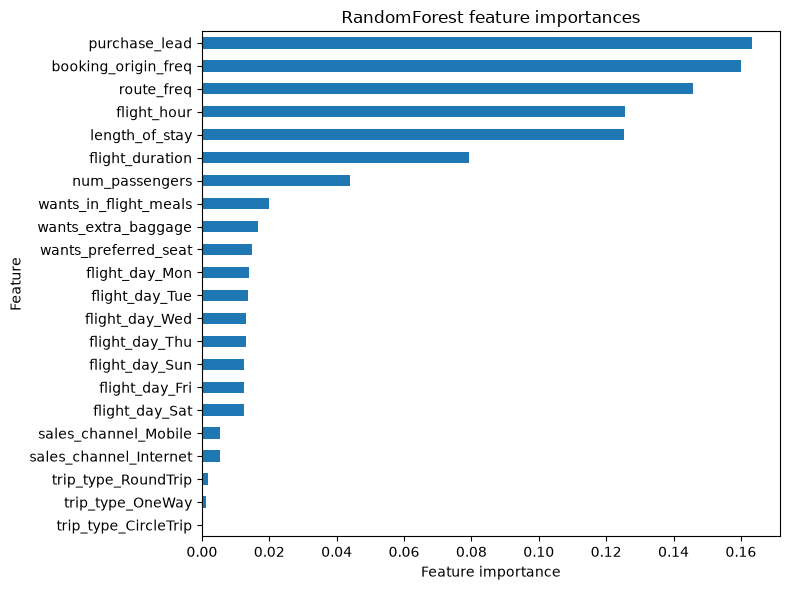

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")
ax.set_title("RandomForest feature importances")
plt.tight_layout()
fig.savefig(r"C:\Users\nmark\Code\BA_Forage\ba-forage-data-science\outputs\feature_importance_baseline.png", dpi=150)
plt.show()

### Baseline model: key stats

**Metrics, explained:**
- **ROC-AUC** (Receiver Operating Characteristic — Area Under Curve): The probability that, given one random completed booking and one random non-completed booking, the model assigns a higher "will complete" score to the completed one is 0.757.

- **Precision**: The fraction of bookings the model predicted would complete that actually did is 0.398. That's ~2.6x better than the ~15% base rate of guessing at random, but still means most of the model's positive predictions are wrong.

- **Recall**: The fraction of bookings that actually completed that the model correctly caught is 0.289, meaning it misses roughly 71% of true completions.

- **F1**: The harmonic mean of precision and recall is 0.335 — a single number that penalizes models that are lopsided toward one or the other.

**Top 5 features by importance**: 
`purchase_lead` (0.163), `booking_origin_freq` (0.160), `route_freq` (0.146), `flight_hour` (0.126), `length_of_stay` (0.125) — together these dominate; `trip_type` and `sales_channel` contribute almost nothing.

## Feature Engineering: `booking_origin` region grouping

**Why this feature, over the other candidates considered (weekend flag, purchase-lead bucketing):**
- RandomForest already finds its own split points on continuous features, and can already combine one-hot flags like `flight_day_Sat`/`flight_day_Sun` if that split were useful.
- `flight_day`'s importances were already near the bottom of the ranking, so a weekend flag is unlikely to add anything the model can't already do itself.
- `booking_origin` is currently only represented by `booking_origin_freq` (how common a country is in the dataset), which is already one of the top 3 most important features.
- Frequency alone can't tell the model "these countries behave similarly" — a coarser region/continent grouping adds genuinely new information.
- Should generalize better for rare countries that currently sit on tiny, noisy frequency counts.

In [17]:
country_to_region = {
    "Afghanistan": "Asia", "Algeria": "Africa", "Argentina": "South America",
    "Australia": "Oceania", "Austria": "Europe", "Bahrain": "Middle East",
    "Bangladesh": "Asia", "Belarus": "Europe", "Belgium": "Europe",
    "Bhutan": "Asia", "Brazil": "South America", "Brunei": "Asia",
    "Bulgaria": "Europe", "Cambodia": "Asia", "Canada": "North America",
    "Chile": "South America", "China": "Asia", "Colombia": "South America",
    "Croatia": "Europe", "Cyprus": "Europe", "Czech Republic": "Europe",
    "Czechia": "Europe", "Denmark": "Europe", "Egypt": "Africa",
    "Estonia": "Europe", "Finland": "Europe", "France": "Europe",
    "Germany": "Europe", "Ghana": "Africa", "Gibraltar": "Europe",
    "Greece": "Europe", "Guam": "Oceania", "Guatemala": "North America",
    "Hong Kong": "Asia", "Hungary": "Europe", "India": "Asia",
    "Indonesia": "Asia", "Iran": "Middle East", "Iraq": "Middle East",
    "Ireland": "Europe", "Israel": "Middle East", "Italy": "Europe",
    "Japan": "Asia", "Jordan": "Middle East", "Kazakhstan": "Asia",
    "Kenya": "Africa", "Kuwait": "Middle East", "Laos": "Asia",
    "Lebanon": "Middle East", "Macau": "Asia", "Malaysia": "Asia",
    "Maldives": "Asia", "Malta": "Europe", "Mauritius": "Africa",
    "Mexico": "North America", "Mongolia": "Asia", "Myanmar (Burma)": "Asia",
    "Nepal": "Asia", "Netherlands": "Europe", "New Caledonia": "Oceania",
    "New Zealand": "Oceania", "Nicaragua": "North America",
    "Norfolk Island": "Oceania", "Norway": "Europe", "Oman": "Middle East",
    "Pakistan": "Asia", "Panama": "North America", "Papua New Guinea": "Oceania",
    "Paraguay": "South America", "Peru": "South America", "Philippines": "Asia",
    "Poland": "Europe", "Portugal": "Europe", "Qatar": "Middle East",
    "Romania": "Europe", "Russia": "Europe", "Réunion": "Africa",
    "Saudi Arabia": "Middle East", "Seychelles": "Africa", "Singapore": "Asia",
    "Slovakia": "Europe", "Slovenia": "Europe", "Solomon Islands": "Oceania",
    "South Africa": "Africa", "South Korea": "Asia", "Spain": "Europe",
    "Sri Lanka": "Asia", "Svalbard & Jan Mayen": "Europe", "Sweden": "Europe",
    "Switzerland": "Europe", "Taiwan": "Asia", "Tanzania": "Africa",
    "Thailand": "Asia", "Timor-Leste": "Asia", "Tonga": "Oceania",
    "Tunisia": "Africa", "Turkey": "Middle East", "Ukraine": "Europe",
    "United Arab Emirates": "Middle East", "United Kingdom": "Europe",
    "United States": "North America", "Vanuatu": "Oceania", "Vietnam": "Asia",
    "(not set)": "Unknown",
}

df["booking_origin_region"] = df["booking_origin"].map(country_to_region)

unmapped = df.loc[df["booking_origin_region"].isna(), "booking_origin"].unique()
print("Unmapped values:", unmapped)
print()
print(df["booking_origin_region"].value_counts())

Unmapped values: <StringArray>
[]
Length: 0, dtype: str

booking_origin_region
Asia             29090
Oceania          18765
Europe             574
North America      522
Middle East        143
Unknown             78
Africa              68
South America       41
Name: count, dtype: int64


### Retrain with region-grouped `booking_origin`

Rebuilding `df_encoded` to add one-hot `booking_origin_region` columns alongside the existing `booking_origin_freq`, then re-running the same train/test split, model, cross-validation, test evaluation, and feature importance steps as before, so the results are directly comparable to the baseline above.

In [18]:
df_encoded = pd.get_dummies(
    df, columns=["sales_channel", "trip_type", "flight_day", "booking_origin_region"], drop_first=False
)
df_encoded["route_freq"] = df["route"].map(df["route"].value_counts())
df_encoded["booking_origin_freq"] = df["booking_origin"].map(df["booking_origin"].value_counts())
df_encoded = df_encoded.drop(columns=["route", "booking_origin"])

X = df_encoded.drop(columns=["booking_complete"])
y = df_encoded["booking_complete"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    model, X_train, y_train, cv=cv,
    scoring=["roc_auc", "precision", "recall", "f1"]
)

for metric in ["roc_auc", "precision", "recall", "f1"]:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {scores.round(3)})")

roc_auc: 0.760 +/- 0.004  (folds: [0.766 0.762 0.757 0.755 0.762])
precision: 0.388 +/- 0.010  (folds: [0.405 0.382 0.394 0.378 0.381])
recall: 0.304 +/- 0.006  (folds: [0.308 0.298 0.307 0.296 0.31 ])
f1: 0.341 +/- 0.007  (folds: [0.35  0.335 0.345 0.332 0.342])


In [20]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      8379
           1       0.38      0.31      0.35      1478

    accuracy                           0.82      9857
   macro avg       0.63      0.61      0.62      9857
weighted avg       0.81      0.82      0.81      9857

ROC-AUC: 0.753
Confusion matrix:
 [[7636  743]
 [1013  465]]


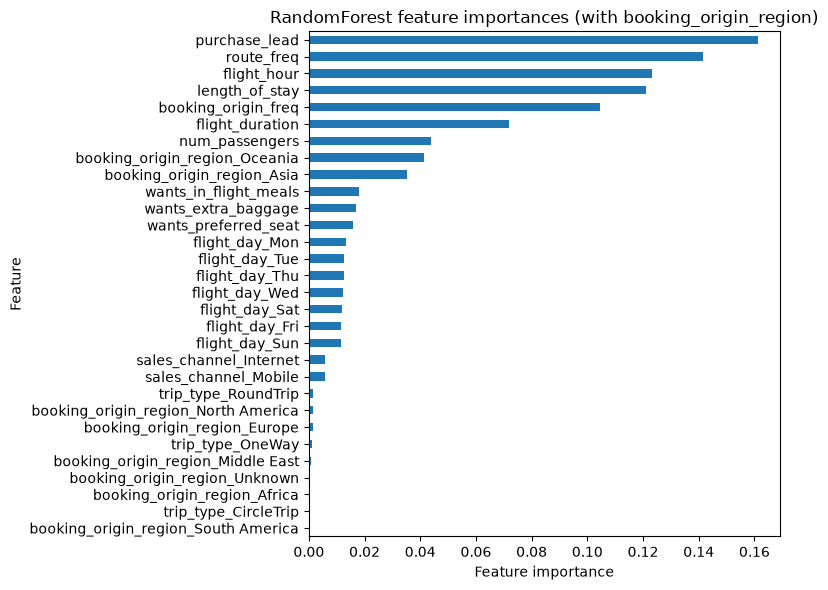

In [21]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature importance")
ax.set_ylabel("Feature")
ax.set_title("RandomForest feature importances (with booking_origin_region)")
plt.tight_layout()
fig.savefig(r"C:\Users\nmark\Code\BA_Forage\ba-forage-data-science\outputs\feature_importance_region.png", dpi=150)
plt.show()

### `booking_origin_region` — impact summary

| Metric | Before | After | Change |
|---|---|---|---|
| CV ROC-AUC | 0.757 | 0.760 | +0.003 |
| CV Recall | 0.289 | 0.303 | +0.014 |
| CV F1 | 0.335 | 0.341 | +0.006 |
| Test ROC-AUC | 0.752 | 0.754 | +0.002 |
| Test Recall | 0.29 | 0.31 | +0.02 |
| Test Precision | 0.39 | 0.39 | ~flat |
| Test F1 | 0.33 | 0.35 | +0.02 |

Grouping `booking_origin` into continent-level regions gave a small, consistent improvement — confirmed on both cross-validation and the untouched test set, so it's a real signal rather than noise. The gain is concentrated in recall/F1 (the model now catches 462 of 1,478 actual completions vs. 430 before), while precision stayed essentially flat. Not a dramatic jump, but directionally correct and cheap to keep in the final model.